# Projet Machine Learning — Prediction du Diabete


In [3]:
# installer les dependances si elles ne sont pas deja presentes
# executer cette cellule une seule fois avant le reste du notebook
!pip install numpy pandas matplotlib seaborn scikit-learn -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)
print("librairies chargees")

librairies chargees


## 2. Chargement et analyse exploratoire (EDA)

Le fichier `diabetes.csv` se trouve dans le meme dossier que ce notebook. On le charge directement avec pandas.


In [5]:
# chargement depuis le fichier local
df = pd.read_csv("diabetes.csv")

print("Dimensions :", df.shape)
df.head()

Dimensions : (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64

Proportion :
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


C:\Users\P15\AppData\Local\Temp\ipykernel_27672\27364373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


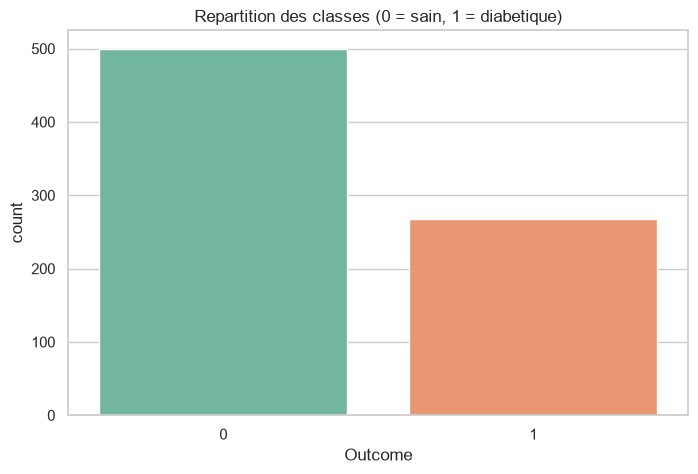

In [8]:
# distribution de la variable cible
print(df['Outcome'].value_counts())
print("\nProportion :")
print(df['Outcome'].value_counts(normalize=True).round(3))

sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title("Repartition des classes (0 = sain, 1 = diabetique)")
plt.show()

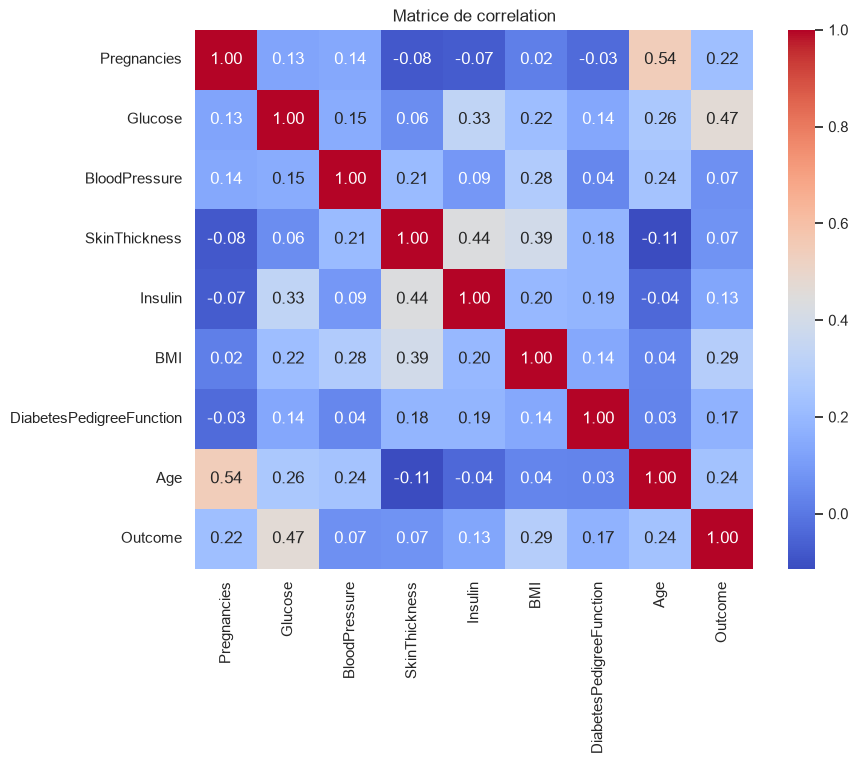

In [9]:
# matrice de correlation
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de correlation")
plt.show()

## 3. Detection des anomalies




In [11]:
# comptage des 0 impossibles
cols_zero_impossibles = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Nombre de 0 impossibles par colonne :")
print((df[cols_zero_impossibles] == 0).sum())

Nombre de 0 impossibles par colonne :
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


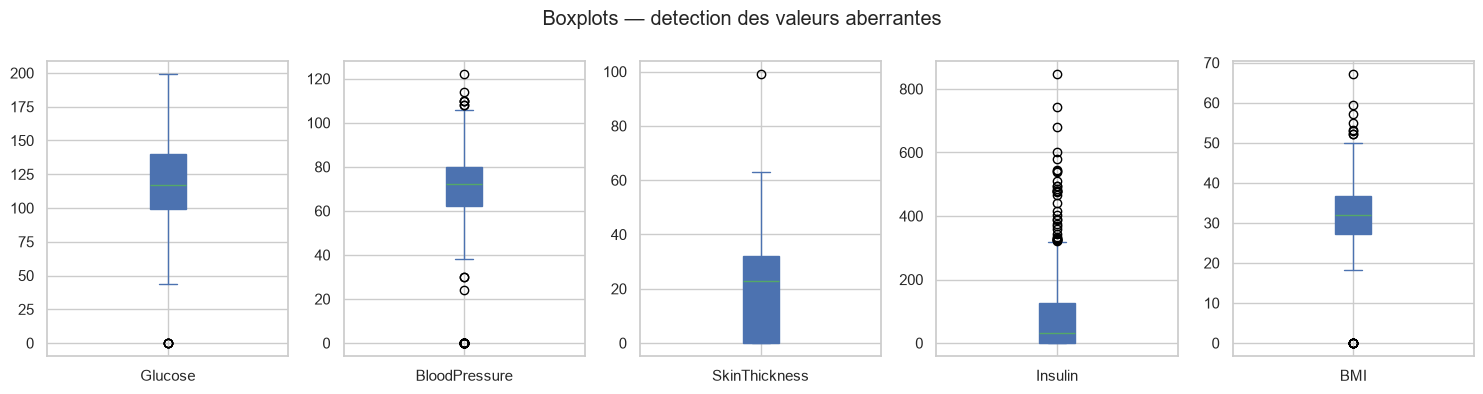

In [12]:
# visualisation des valeurs aberrantes (boxplots)
df[cols_zero_impossibles].plot(kind='box', subplots=True, layout=(1, 5),
                               figsize=(15, 4), patch_artist=True)
plt.suptitle("Boxplots — detection des valeurs aberrantes")
plt.tight_layout()
plt.show()

## 4. Pretraitement et Feature Engineering

Etapes :
1. Remplacer les zeros impossibles par `NaN`.
2. Imputer par la mediane conditionnee a la classe (plus pertinent qu'une mediane globale).
3. Creer quelques nouvelles variables : categories d'IMC, d'age, de glycemie.
4. Standardiser toutes les variables.


In [13]:
# remplacer les 0 impossibles par NaN
df_clean = df.copy()
df_clean[cols_zero_impossibles] = df_clean[cols_zero_impossibles].replace(0, np.nan)
print("Valeurs manquantes apres remplacement :")
print(df_clean.isnull().sum())

Valeurs manquantes apres remplacement :
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [14]:
# imputation par la mediane conditionnee a la classe (Outcome)
for col in cols_zero_impossibles:
    df_clean[col] = df_clean.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

print("Valeurs manquantes apres imputation :", df_clean.isnull().sum().sum())

Valeurs manquantes apres imputation : 0


In [15]:
# feature engineering : variables categoriales derivees
df_clean['BMI_cat'] = pd.cut(df_clean['BMI'],
                             bins=[0, 18.5, 25, 30, 100],
                             labels=[0, 1, 2, 3]).astype(int)  # maigre/normal/surpoids/obese

df_clean['Age_cat'] = pd.cut(df_clean['Age'],
                             bins=[20, 30, 45, 100],
                             labels=[0, 1, 2]).astype(int)      # jeune/moyen/age

df_clean['Glucose_cat'] = pd.cut(df_clean['Glucose'],
                                 bins=[0, 100, 125, 300],
                                 labels=[0, 1, 2]).astype(int)  # normal/pre-diabete/diabete

df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_cat,Age_cat,Glucose_cat
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,3,2,2
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,2,1,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,1,1,2
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2,0,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,3,1,2


In [16]:
# separation features / cible + split train/test stratifie
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# standardisation (fit sur train uniquement pour eviter le data leakage)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train :", X_train_s.shape, " | Test :", X_test_s.shape)

Train : (614, 11)  | Test : (154, 11)


## 5. Entrainement et comparaison des modeles

On teste 5 algorithmes de classification classiques et on les compare sur plusieurs metriques. Vu le desequilibre des classes, on regarde principalement le F1-score et l'AUC.


In [17]:
models = {
    'Regression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                   KNeighborsClassifier(),
    'SVM':                   SVC(probability=True, random_state=42),
    'Random Forest':         RandomForestClassifier(random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(random_state=42),
}

resultats = []
for nom, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    resultats.append({
        'Modele':    nom,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1-score':  round(f1_score(y_test, y_pred), 3),
        'AUC':       round(roc_auc_score(y_test, y_proba), 3),
    })

df_resultats = pd.DataFrame(resultats).sort_values('F1-score', ascending=False).reset_index(drop=True)
df_resultats

c:\Users\P15\OneDrive\Desktop\jawedi\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Modele,Accuracy,Precision,Recall,F1-score,AUC
0,Random Forest,0.883,0.846,0.815,0.830,0.949
1,Gradient Boosting,0.877,0.818,0.833,0.826,0.955
2,SVM,0.825,0.745,0.759,0.752,0.894
3,KNN,0.792,0.704,0.704,0.704,0.851
4,Regression Logistique,0.740,0.640,0.593,0.615,0.837


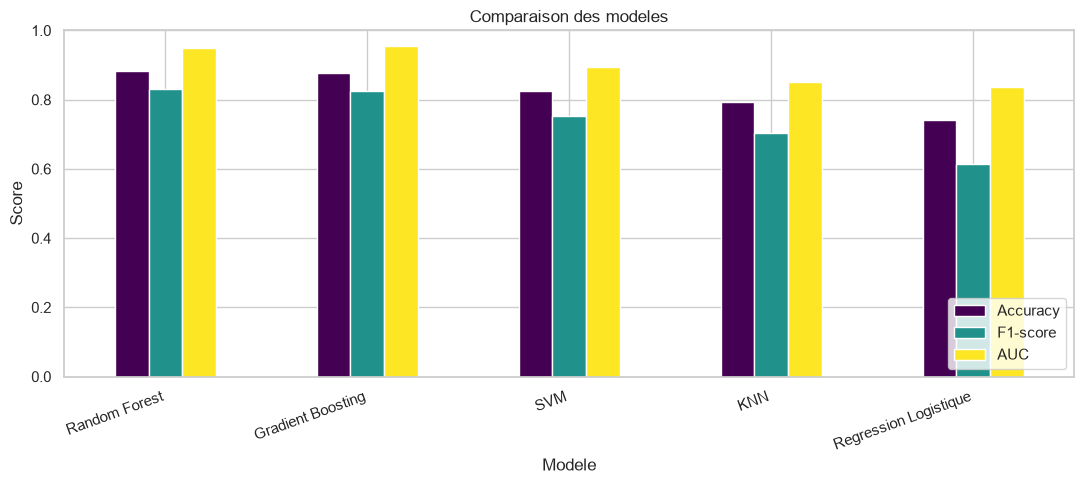

In [18]:
# comparaison visuelle des modeles
df_plot = df_resultats.set_index('Modele')[['Accuracy', 'F1-score', 'AUC']]
df_plot.plot(kind='bar', figsize=(11, 5), colormap='viridis')
plt.title("Comparaison des modeles")
plt.ylabel("Score")
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Optimisation du meilleur modele (GridSearch)

On cherche les meilleurs hyperparametres du Gradient Boosting via une validation croisee a 5 folds.


In [19]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4],
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_s, y_train)

print("Meilleurs hyperparametres :", grid.best_params_)
print("Meilleur F1 (validation croisee) :", round(grid.best_score_, 3))

best_model = grid.best_estimator_

Meilleurs hyperparametres : {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Meilleur F1 (validation croisee) : 0.84


## 7. Evaluation finale du modele optimise


In [20]:
y_pred  = best_model.predict(X_test_s)
y_proba = best_model.predict_proba(X_test_s)[:, 1]

print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=['Sain (0)', 'Diabetique (1)']))

=== Rapport de classification ===
                precision    recall  f1-score   support

      Sain (0)       0.88      0.89      0.89       100
Diabetique (1)       0.79      0.78      0.79        54

      accuracy                           0.85       154
     macro avg       0.84      0.83      0.84       154
  weighted avg       0.85      0.85      0.85       154



In [21]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1-score  : {f1:.3f}")

Accuracy  : 0.851
Precision : 0.792
Recall    : 0.778
F1-score  : 0.785


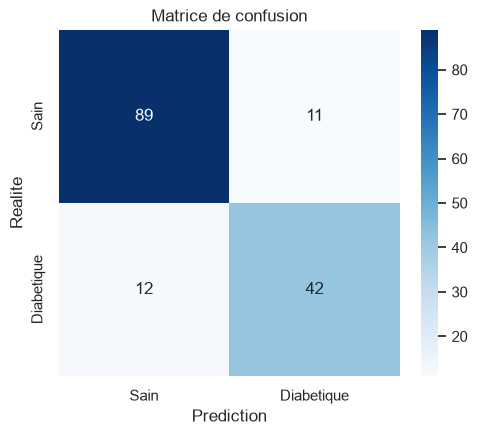

In [22]:
# matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sain', 'Diabetique'],
            yticklabels=['Sain', 'Diabetique'])
plt.xlabel("Prediction"); plt.ylabel("Realite")
plt.title("Matrice de confusion")
plt.show()

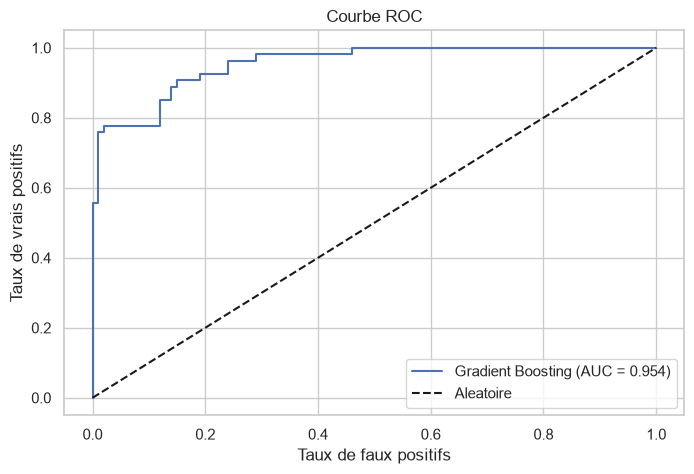

In [23]:
# courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatoire')
plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC")
plt.legend()
plt.show()

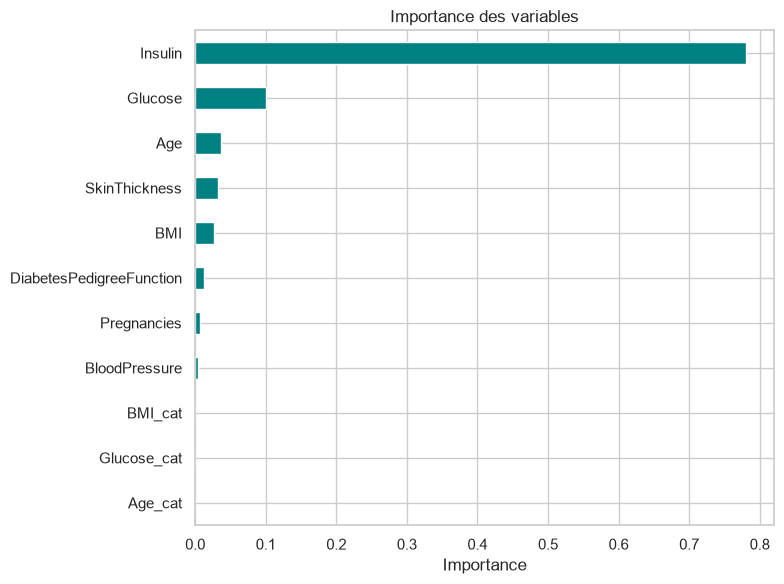

In [24]:
# importance des variables
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', 
                 figsize=(8, 6), color='teal')
plt.title("Importance des variables")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# --- prediction interactive ---
# remplir chaque champ et appuyer sur Entree

Pregnancies              = int(input("Nombre de grossesses        : "))
Glucose                  = float(input("Glycemie (mg/dL)           : "))
BloodPressure            = float(input("Pression arterielle (mm Hg): "))
SkinThickness            = float(input("Epaisseur pli cutane (mm)  : "))
Insulin                  = float(input("Insuline (mu U/ml)         : "))
BMI                      = float(input("IMC (kg/m2)                : "))
DiabetesPedigreeFunction = float(input("Score heredite diabete     : "))
Age                      = int(input("Age (annees)               : "))

# calcul automatique des categories derivees
BMI_cat     = int(np.digitize(BMI,     [18.5, 25, 30]))
Age_cat     = int(np.digitize(Age,     [30, 45]))
Glucose_cat = int(np.digitize(Glucose, [100, 125]))

# assembler et predire
exemple = pd.DataFrame(
    [[Pregnancies, Glucose, BloodPressure, SkinThickness,
      Insulin, BMI, DiabetesPedigreeFunction, Age,
      BMI_cat, Age_cat, Glucose_cat]],
    columns=X.columns
)

exemple_s   = scaler.transform(exemple)
prediction  = best_model.predict(exemple_s)[0]
probabilite = best_model.predict_proba(exemple_s)[0][1]

resultat = "Diabetique" if prediction == 1 else "Non diabetique"
print(f"Resultat    : {resultat}")
print(f"Probabilite : {probabilite:.1%}")